# Phần 1. NumPy trong workflow ML/DL

Các bài dưới đây dùng dữ liệu nhỏ để mô phỏng preprocessing, inference và xử lý
tensor trong một pipeline thực tế.

In [62]:
STUDENT_NAME = "Nguyễn Gia Bảo"  # TODO: Họ và tên
STUDENT_ID = "2510024"    # TODO: MSSV

print(f"Student: {STUDENT_NAME} ({STUDENT_ID})")

Student: Nguyễn Gia Bảo (2510024)


In [63]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (8, 4.8)

DATA_CANDIDATES = [
    Path("week02/numpy-pandas-eda-hw/data/automobile_raw.csv"),
    Path("data/automobile_raw.csv"),
    Path("../data/automobile_raw.csv"),
]
DATA_PATH = next((path for path in DATA_CANDIDATES if path.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("Không tìm thấy data/automobile_raw.csv")

print("Data path:", DATA_PATH.resolve())

Data path: D:\mliotlab\mliot-pyml-2026-hw\week02\numpy-pandas-eda-hw\data\automobile_raw.csv


## N1. Stable softmax cho batch logits

Một classifier trả về `logits` có shape `(batch_size, num_classes)`. Tính softmax
theo từng mẫu bằng cách trừ giá trị lớn nhất trên mỗi hàng trước khi gọi `np.exp`.
Cách viết này tránh overflow khi logits có giá trị lớn.

**Biến đầu ra bắt buộc**

- `shifted_logits`: logits sau khi trừ row-wise maximum.
- `class_probabilities`: xác suất mỗi class, mỗi hàng có tổng bằng 1.
- `predicted_classes`: class có xác suất lớn nhất của từng mẫu.
- `confidence_scores`: xác suất lớn nhất của từng mẫu.

In [64]:
logits = np.array([
    [2.0, 1.0, 0.1],
    [1000.0, 1001.0, 999.0],
    [-2.0, -1.0, 3.0],
    [0.5, 0.5, 0.5],
], dtype=np.float64)

In [65]:
# TODO N1
shifted_logits = logits - np.max(logits, axis = 1, keepdims=True)
exp_logits = np.exp(shifted_logits)
class_probabilities = exp_logits / np.sum(exp_logits, axis = 1, keepdims=True)
predicted_classes = np.argmax(class_probabilities, axis = 1)
confidence_scores = np.max(class_probabilities , axis = 1)

In [66]:
required = [
    "shifted_logits",
    "class_probabilities",
    "predicted_classes",
    "confidence_scores",
]
if not all(name in globals() for name in required):
    print("Complete N1 to run this self-check.")
else:
    assert class_probabilities.shape == logits.shape
    assert np.all(np.isfinite(class_probabilities))
    assert np.allclose(class_probabilities.sum(axis=1), 1.0)
    assert predicted_classes.shape == (logits.shape[0],)
    assert confidence_scores.shape == (logits.shape[0],)
    print("N1 self-check passed")

N1 self-check passed


## N2. Chuẩn hóa train và validation không gây leakage

Mỗi hàng là một mẫu, mỗi cột là một feature. Tính mean/std **chỉ từ `X_train`**,
sau đó dùng cùng thống kê để transform cả train và validation.

**Biến đầu ra bắt buộc**

- `train_feature_mean`, `train_feature_std`: shape `(4,)`.
- `X_train_scaled`: train set đã chuẩn hóa.
- `X_val_scaled`: validation set dùng thống kê từ train.

In [67]:
# Features: height_cm, weight_kg, activity_hours, age
X_train = np.array([
    [170.0, 65.0, 1.2, 22.0],
    [180.0, 80.0, 2.4, 35.0],
    [160.0, 50.0, 0.8, 19.0],
    [175.0, 70.0, 1.5, 28.0],
    [168.0, 60.0, 1.0, 24.0],
    [182.0, 90.0, 3.0, 41.0],
])

X_val = np.array([
    [172.0, 68.0, 1.4, 26.0],
    [190.0, 95.0, 3.4, 45.0],
])

In [68]:
# TODO N2
train_feature_mean = np.mean(X_train, axis = 0)
train_feature_std = np.std(X_train, axis = 0 )
X_train_scaled = (X_train - train_feature_mean)/train_feature_std
X_val_scaled = (X_val - train_feature_mean)/train_feature_std

In [69]:
required = [
    "train_feature_mean",
    "train_feature_std",
    "X_train_scaled",
    "X_val_scaled",
]
if not all(name in globals() for name in required):
    print("Complete N2 to run this self-check.")
else:
    assert X_train_scaled.shape == X_train.shape
    assert X_val_scaled.shape == X_val.shape
    assert np.allclose(X_train_scaled.mean(axis=0), 0.0)
    assert np.allclose(X_train_scaled.std(axis=0), 1.0)
    print("N2 self-check passed")

N2 self-check passed


## N3. Tạo review queue sau inference

Giả sử `class_probabilities` đến từ N1. Một prediction cần được kiểm tra thủ công
nếu dự đoán sai **hoặc** confidence nhỏ hơn `0.70`.

**Biến đầu ra bắt buộc**

- `correct_mask`
- `high_confidence_mask`
- `review_mask`
- `review_indices`

In [70]:
true_labels = np.array([0, 2, 2, 1])
confidence_threshold = 0.70

In [71]:
# TODO N3
correct_mask = true_labels == predicted_classes
high_confidence_mask = confidence_scores >= confidence_threshold
review_mask = (~correct_mask) | (~high_confidence_mask)
review_indices = np.where(review_mask)[0]

## N4. Tiền xử lý và augment một batch ảnh

`image_batch_uint8` có layout `(B, H, W, C)`. Chuyển batch về `float32` trong đoạn
`[0, 1]`, sau đó tạo một batch mới được flip ngang. Batch augment phải có bộ nhớ
độc lập để việc chỉnh sửa không làm thay đổi batch đã normalize.

Sau khi tạo batch augment, đặt pixel `augmented_batch[0, 0, 0, 0] = 1.0`.

**Biến đầu ra bắt buộc:** `normalized_batch`, `augmented_batch`.

In [72]:
image_batch_uint8 = (
    np.arange(2 * 4 * 4 * 3, dtype=np.uint8)
    .reshape(2, 4, 4, 3)
)

In [73]:
# TODO N4
normalized_batch = image_batch_uint8.astype(np.float32) / 255.0
augmented_batch = np.flip(normalized_batch, axis = 2).copy()
augmented_batch[0, 0, 0, 0] = 1.0

# Phần 2. EDA với Automobile

Đọc `data/data_dictionary.md` trước khi xử lý.

## Câu hỏi mở đầu

1. Mỗi dòng đại diện cho đối tượng gì?
2. Ký hiệu missing value trong CSV là gì?
3. `symboling` có ý nghĩa gì?

**Trả lời**

<!-- Viết câu trả lời tại đây. -->

1. Mỗi dòng đại diện cho một mẫu xe trong bộ 1985 Auto Imports
2. Kí hiệu missing value trong CSV là `?`
3. `symboling` có ý là mức đánh giá rủi ro bảo hiểm

## D1. Load và inspect raw CSV

Load dữ liệu sao cho dấu `?` vẫn là chuỗi để quan sát ảnh hưởng tới dtype.

**Biến đầu ra bắt buộc**

- `raw_df`: DataFrame raw.
- `raw_shape`: tuple.
- `raw_missing_marker_count`: tổng số dấu `?`.

In [74]:
# TODO D1
raw_df = pd.read_csv("data/automobile_raw.csv")
raw_shape = raw_df.shape
raw_missing_marker_count = (raw_df == '?').sum().sum()



## D2. Missing values và dtype

1. Thay `?` bằng `np.nan`.
2. Chuyển các cột trong `NUMERIC_COLUMNS` bằng `pd.to_numeric`.
3. Tạo báo cáo missing.

**Biến đầu ra bắt buộc:** `df_clean`, `missing_by_column`.

In [75]:
NUMERIC_COLUMNS = ['symboling', 'normalized_losses', 'wheel_base', 'length', 'width', 'height', 'curb_weight', 'engine_size', 'bore', 'stroke', 'compression_ratio', 'horsepower', 'peak_rpm', 'city_mpg', 'highway_mpg', 'price']

In [76]:
# TODO D2
df_clean = raw_df.replace('?', np.nan)
for column in NUMERIC_COLUMNS:
    df_clean[column] = pd.to_numeric(df_clean[column])
missing_by_column = df_clean.isna().sum()
print(missing_by_column)

symboling             0
normalized_losses    41
make                  0
fuel_type             0
aspiration            0
num_doors             2
body_style            0
drive_wheels          0
engine_location       0
wheel_base            0
length                0
width                 0
height                0
curb_weight           0
engine_type           0
num_cylinders         0
engine_size           0
fuel_system           0
bore                  4
stroke                4
compression_ratio     0
horsepower            2
peak_rpm              2
city_mpg              0
highway_mpg           0
price                 4
dtype: int64


### Giải thích cách làm sạch dữ liệu

- Vì sao không nên fill tất cả numeric columns bằng cùng một giá trị?
- Với `price`, lựa chọn drop hay fill phù hợp hơn cho bài EDA này? Vì sao?
- `normalized_losses` thiếu nhiều dữ liệu hơn các cột khác. Điều này ảnh hưởng thế nào?

**Nhận xét**

<!-- Viết 3--6 câu tại đây. -->
- Không nên fill tất cả các numeric columns bằng cùng một giá trị vì một cột có đặc điểm, ý nghĩa riêng
- Với `price`, ta lựa chọn drop vì số missing không nhiều, bỏ đi cũng không ảnh hưởng nhiều đến tổng thể
- `normalized_losses` thiếu nhiều dữ liệu hơn các cột khác, làm ảnh hưởng:
    + Nếu fill thì sẽ làm sai lệch dữ liệu
    + Nếu drop thì sẽ làm mất đi nhiều dữ liệu
    + Các phép tính mean, std,... trên cột đó trở nên ít tin cậy vì có quá ít mẫu

## D3. DataFrame sang NumPy

Dùng sáu cột trong `AUTO_FEATURES`. Drop các dòng thiếu ít nhất một trong
sáu cột, sau đó chuyển sang `float64` NumPy array và chuẩn hóa theo feature.

**Biến đầu ra bắt buộc**

- `analysis_df`
- `X_auto`
- `auto_feature_mean`
- `auto_feature_std`
- `X_auto_scaled`

In [77]:
AUTO_FEATURES = ['curb_weight', 'engine_size', 'horsepower', 'city_mpg', 'highway_mpg', 'price']

In [78]:
# TODO D3
analysis_df = df_clean[AUTO_FEATURES].dropna()
X_auto = analysis_df.to_numpy(dtype=np.float64)
auto_feature_mean = np.mean(X_auto, axis = 0)
auto_feature_std = np.std(X_auto, axis = 0)
X_auto_scaled = (X_auto - auto_feature_mean) / auto_feature_std

## D4. Outlier theo price z-score

Tính z-score của `price` bằng NumPy. Một dòng được xem là outlier trong bài
này khi `abs(z) > 2`.

**Biến đầu ra bắt buộc:** `price_z`, `price_outlier_mask`, `price_outliers`.

In [79]:
# TODO D4
price_index = analysis_df["price"].to_numpy(dtype=np.float64)
price_z = (price_index - np.mean(price_index, axis = 0))/np.std(price_index, axis = 0)
price_outlier_mask = np.abs(price_z) > 2
price_outliers = analysis_df[price_outlier_mask]

## D5. Correlation và GroupBy

**Biến đầu ra bắt buộc**

- `engine_price_corr`: Pearson correlation tính bằng NumPy.
- `price_by_body_style`: Series mean price theo `body_style`, sort index.

In [80]:
# TODO D5
engine_price_corr = np.corrcoef(df_clean["engine_size"].to_numpy(), df_clean["price"].to_numpy())[0][1]
price_by_body_style = df_clean.groupby("body_style")["price"].mean().sort_index()

# Phần 3. Visualization và insight

Mỗi biểu đồ cần:

1. một câu hỏi;
2. title, axis labels và unit;
3. lựa chọn chart phù hợp;
4. 1--2 câu nhận xét ngay dưới chart.

## M2.1 Price phân phối như thế nào?

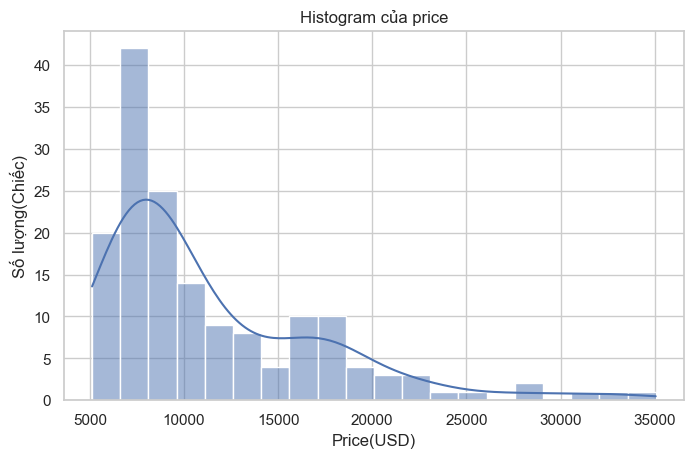

In [81]:
# TODO M2.1: histogram/KDE của price
sns.histplot(
    df_clean.dropna(),
    x = "price",
    kde = True,
    bins= 20)
plt.title("Histogram của price")
plt.xlabel("Price(USD)")
plt.ylabel("Số lượng(Chiếc)")
plt.show()

**Nhận xét:** <!-- 1--2 câu -->
- Đa số xe có giá thấp đến trung bình\
- Đồ thị lệch phải, một số xe có giá trị cao tạo thành các outlier

## M2.2 Dataset có cân bằng theo body style không?

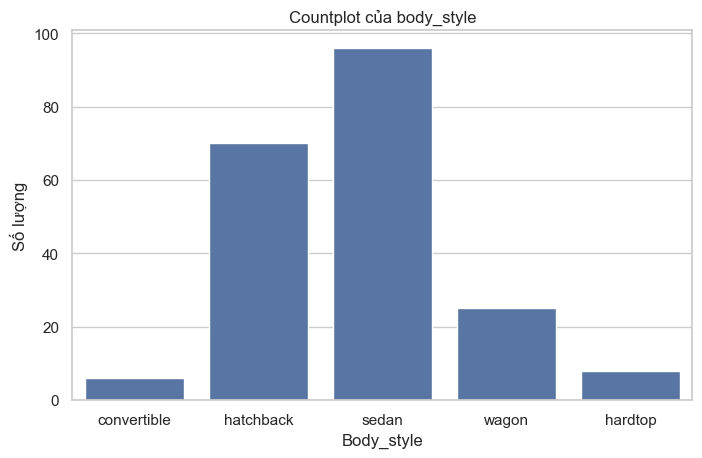

In [82]:
# TODO M2.2: countplot của body_style
sns.countplot(
    df_clean,
    x = "body_style"
)
plt.title("Countplot của body_style")
plt.xlabel("Body_style")
plt.ylabel("Số lượng")
plt.show()

**Nhận xét:** <!-- 1--2 câu -->
- Sedan là loại xe có số lượng cao nhất
- Convertible và Hardtop là 2 loại xe có số lượng rất ít so với các loại còn lại

## M2.3 Price khác nhau theo body style ra sao?

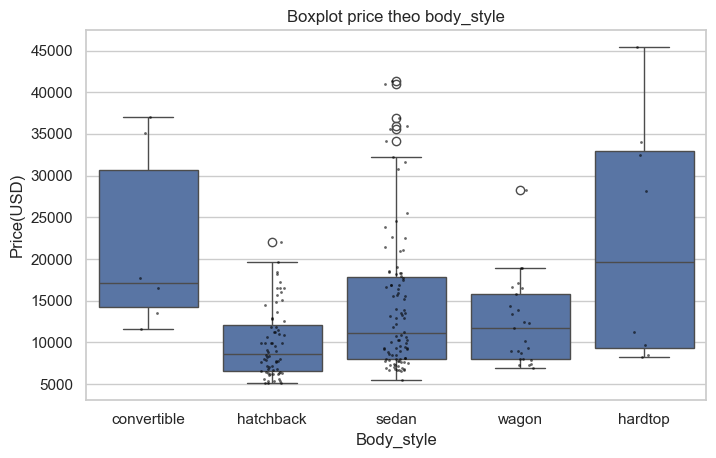

In [83]:
# TODO M2.3: boxplot price theo body_style
sns.boxplot(
    df_clean,
    x = "body_style",
    y = "price"
)

sns.stripplot(
    df_clean,
    x = "body_style",
    y = "price",
    color="black",
    alpha=0.6,
    size = 2,
    jitter = True
)
plt.title("Boxplot price theo body_style")
plt.xlabel("Body_style")
plt.ylabel("Price(USD)")
plt.show()

**Nhận xét:** <!-- 1--2 câu -->
- Có sự khác biệt về giá giữa các loại xe
- Có sự xuất hiện của các outier ở các loại

## M2.4 Engine size liên quan thế nào tới price?

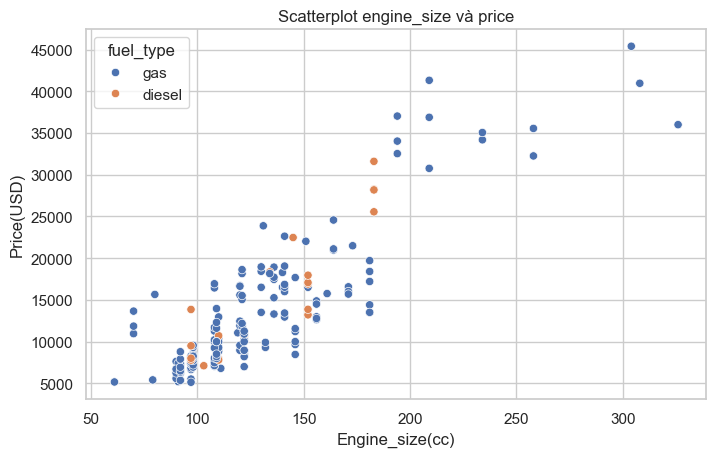

In [84]:
# TODO M2.4: scatterplot engine_size và price, hue=fuel_type
sns.scatterplot(
    df_clean,
    x = "engine_size",
    y = "price",
    hue = "fuel_type"
)

plt.title("Scatterplot engine_size và price")
plt.xlabel("Engine_size(cc)")
plt.ylabel("Price(USD)")
plt.show()

**Nhận xét:** <!-- 1--2 câu -->
- Có sự tương quan giữa dung tích máy và giá của xe, dung tích máy càng lớn giá càng cao
- Các điểm tô màu theo fuel_type giúp quan sát sự khác nhau về tương quan giữa 2 loại nhiên liệu

## M2.5 Các feature numeric tương quan ra sao?

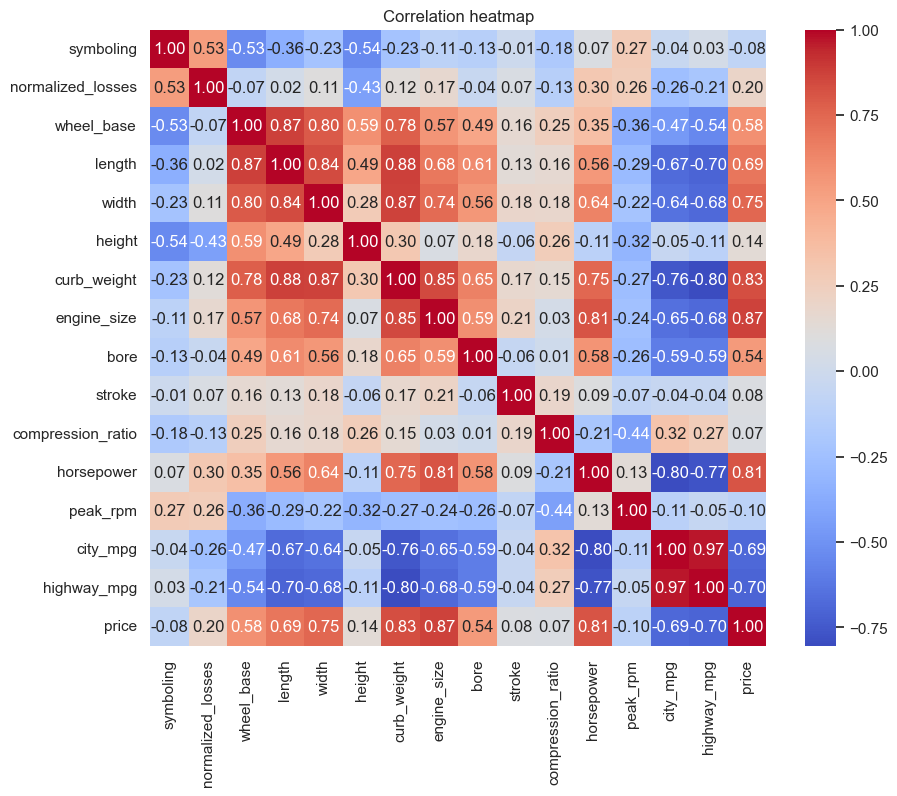

In [85]:
# TODO M2.5: correlation heatmap
plt.figure(figsize=(10, 8))
corr = df_clean.select_dtypes(include = "number").corr()

sns.heatmap(
    corr,
    annot = True,
    fmt = ".2f",
    cmap = "coolwarm",
    square = True
)
plt.title("Correlation heatmap")
plt.show()

**Nhận xét:** <!-- 1--2 câu -->
- price có tương quan dương mạnh với engine_size, horsepower, curb_weight
- city_mpg và highway_mpg tương quan âm với price -> xe tiết kiệm nhiên liệu hơn thì có giá thấp hơn 

## M2.6 Biểu đồ tự chọn

Đặt một câu hỏi mới, chọn chart phù hợp và không lặp nguyên năm biểu đồ trên.

Violinplot của price theo body_style



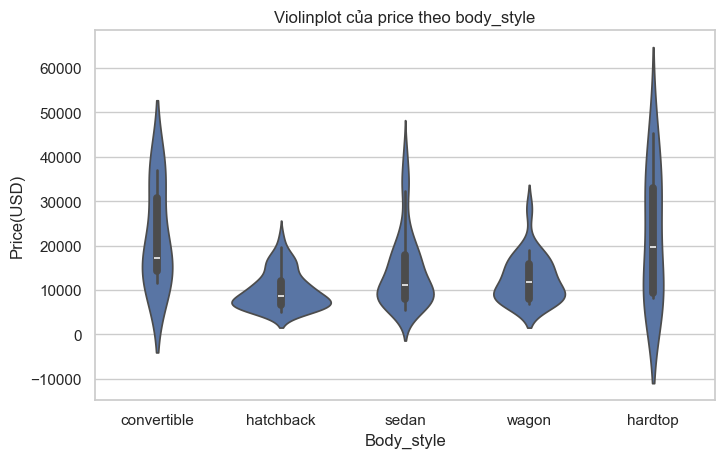

In [86]:
# TODO M2.6: Violinplot của price theo body_style

sns.violinplot(
    df_clean,
    x = "body_style",
    y = "price"
)
plt.title("Violinplot của price theo body_style")
plt.xlabel("Body_style")
plt.ylabel("Price(USD)")

plt.show()


**Nhận xét:** <!-- 1--2 câu -->
- Hardtop và convertible có xu hướng có mức giá cao hơn so với các kiểu thân xe còn lại.
- Hatchback có khoảng giá hẹp và chủ yếu tập trung ở mức giá thấp đến trung bình.

# Tổng hợp

Viết:

- 3--5 phát hiện chính có dẫn chứng;
- ít nhất 2 hạn chế của dataset;
- một ví dụ về correlation không đồng nghĩa causation;
- một câu hỏi nên phân tích tiếp.

## Tổng hợp của sinh viên

<!-- Viết khoảng 150--250 từ. -->

1. 
 - Giá xe có tương quan dương với kích thước động cơ (engine_size), thể hiện qua scatter plot: xe có động cơ lớn thường có giá cao hơn.
 - Các biến số như engine_size, horsepower và curb_weight có tương quan dương khá mạnh với price, được quan sát trên correlation heatmap.
 - Giá xe khác nhau giữa các kiểu thân xe (body_style); violin plot cho thấy hardtop và convertible có xu hướng có mức giá cao hơn, trong khi hatchback chủ yếu tập trung ở mức giá thấp đến trung bình.
 - Dữ liệu có sự phân tán và một số giá trị ngoại lai (outliers), đặc biệt ở các mẫu xe có giá rất cao.
2. 
 - Bộ dữ liệu có giá trị thiếu (missing values) ở một số cột như normalized_losses và horsepower, cần được xử lý trước khi phân tích.
 - Kích thước dữ liệu tương đối nhỏ và chỉ bao gồm một số mẫu xe, nên kết quả phân tích có thể chưa đại diện cho toàn bộ thị trường ô tô.
3.
 - engine_size có tương quan dương với price, nhưng điều đó không có nghĩa động cơ lớn trực tiếp làm tăng giá xe. Giá xe còn chịu ảnh hưởng của nhiều yếu tố khác như thương hiệu, công nghệ, trang bị và chất lượng.
4. Một câu hỏi nên phân tích tiếp
 - Biến nào ảnh hưởng mạnh nhất đến giá xe nếu xây dựng mô hình hồi quy dự đoán (price)?
